          q         R        dR
1  0.002135  2.635225  0.002818
2  0.004271  2.729629  0.001003
3  0.006406  4.130159  0.001009
4  0.008542  5.562537  0.001163
5  0.010677  7.004321  0.001302
q     float64
R     float64
dR    float64
dtype: object
Possible layer/interface thickness information:
Peak 1: z = 158.48 Å, amplitude = 1.000


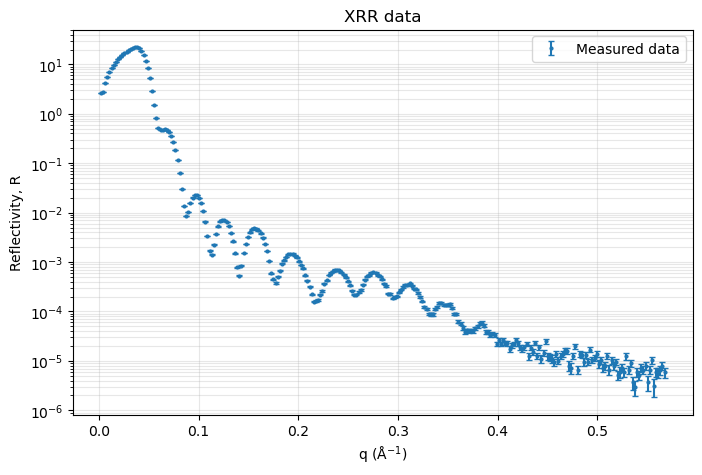

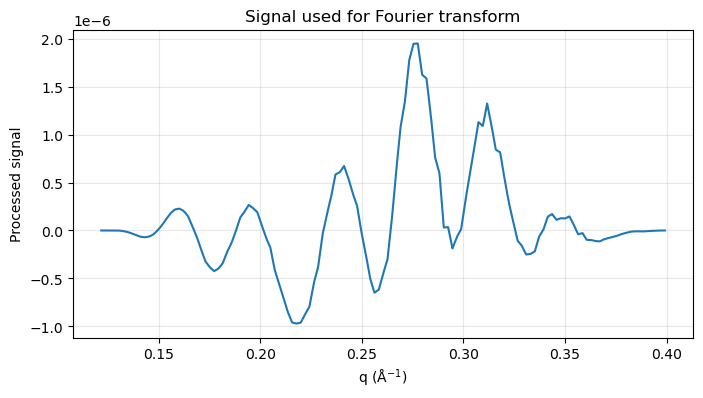

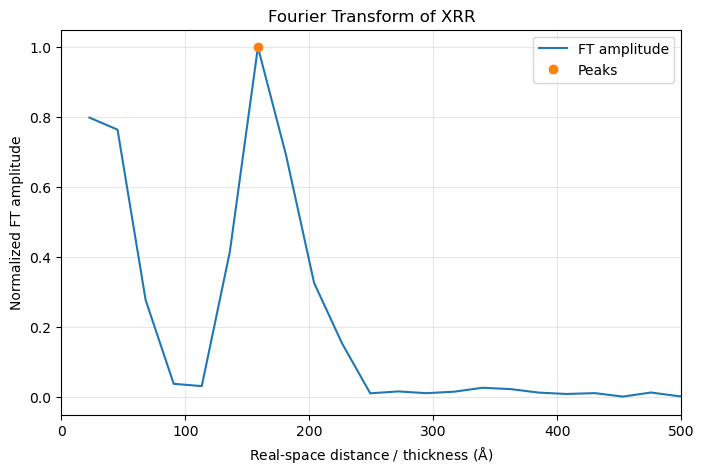

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, windows
from scipy.interpolate import interp1d
import pandas as pd

# =========================
# User setting
# =========================
file_path = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"   # 改成你的 txt 檔案路徑

q_min = 0.12    # 避開 critical edge / total reflection region
q_max = 0.40     # 避開 high-q noise region

use_q4_correction = True
window_type = "hann"   # "hann" or None

# =========================
# 1. Load data
# =========================
df = pd.read_csv(
    file_path,
    sep=r"[\s,]+",
    engine="python",
    comment="#",
    header=None
)

# 如果檔案第一列其實是文字標題，這裡會轉成 NaN 並移除
df = df.iloc[:, :3]
df.columns = ["q", "R", "dR"]

for col in ["q", "R", "dR"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]

q = df["q"].to_numpy(dtype=float)
R = df["R"].to_numpy(dtype=float)
dR = df["dR"].to_numpy(dtype=float)

print(df.head())
print(df.dtypes)

# =========================
# 2. Select useful q range
# =========================
mask = (q >= q_min) & (q <= q_max)
q_sel = q[mask]
R_sel = R[mask]

# Optional: q^4 correction to remove Fresnel-like decay
if use_q4_correction:
    signal = R_sel * q_sel**4
else:
    signal = R_sel.copy()

# Remove slow background by subtracting mean
signal = signal - np.mean(signal)

# =========================
# 3. Interpolate to uniform q grid
# =========================
N = 4096

q_uniform = np.linspace(q_sel.min(), q_sel.max(), N)

interp_func = interp1d(
    q_sel,
    signal,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

signal_uniform = interp_func(q_uniform)

# Apply window to reduce edge artifacts
if window_type == "hann":
    signal_uniform = signal_uniform * windows.hann(N)

# =========================
# 4. Fourier transform
# =========================
dq = q_uniform[1] - q_uniform[0]

FT = np.fft.fft(signal_uniform)
freq = np.fft.fftfreq(N, d=dq)

# XRR relation:
# fringe period Δq ≈ 2π / thickness
# so real-space length z = 2π * frequency
z = 2 * np.pi * freq

# Keep positive z only
pos = z > 0
z_pos = z[pos]
FT_amp = np.abs(FT[pos])

# Normalize
FT_amp = FT_amp / np.max(FT_amp)

# =========================
# 5. Find peaks in Fourier spectrum
# =========================
peaks, props = find_peaks(
    FT_amp,
    height=0.05,
    distance=20
)

peak_z = z_pos[peaks]
peak_amp = FT_amp[peaks]

# Sort peaks by amplitude
order = np.argsort(peak_amp)[::-1]
peak_z = peak_z[order]
peak_amp = peak_amp[order]

print("Possible layer/interface thickness information:")
for i in range(min(10, len(peak_z))):
    print(f"Peak {i+1}: z = {peak_z[i]:.2f} Å, amplitude = {peak_amp[i]:.3f}")

# =========================
# 6. Plot original XRR
# =========================
plt.figure(figsize=(8, 5))
plt.errorbar(q, R, yerr=dR, fmt=".", markersize=4, capsize=2, label="Measured data")
plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("XRR data")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# 7. Plot processed signal
# =========================
plt.figure(figsize=(8, 4))
plt.plot(q_uniform, signal_uniform)
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Processed signal")
plt.title("Signal used for Fourier transform")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# 8. Plot Fourier spectrum
# =========================
plt.figure(figsize=(8, 5))
plt.plot(z_pos, FT_amp, label="FT amplitude")
plt.plot(peak_z[:10], peak_amp[:10], "o", label="Peaks")

plt.xlabel(r"Real-space distance / thickness ($\mathrm{\AA}$)")
plt.ylabel("Normalized FT amplitude")
plt.title("Fourier Transform of XRR")
plt.xlim(0, 500)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
import pandas as pd

# ===== 檔案路徑 =====
input_file = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"
output_file = r"D:\course\MSE461\lab1\reduced_XRR_data.csv"

# ===== 讀取 txt =====
df = pd.read_csv(
    input_file,
    sep=r"[\s,]+",     # 自動處理空白 / tab / 逗號
    engine="python",
    comment="#",       # 忽略註解行（如果有）
    header=None        # 如果沒有 header
)

# ===== 存成 csv =====
df.to_csv(output_file, index=False, header=False)

print("轉換完成 →", output_file)

轉換完成 → D:\course\MSE461\lab1\reduced_XRR_data.csv


          q         R        dR
1  0.002135  2.635225  0.002818
2  0.004271  2.729629  0.001003
3  0.006406  4.130159  0.001009
4  0.008542  5.562537  0.001163
5  0.010677  7.004321  0.001302
q     float64
R     float64
dR    float64
dtype: object

Thickness from maxima:
Average Δq = 0.0384 ± 0.0037 Å^-1
t ≈ 163.53 Å = 16.35 nm

Thickness from minima:
Average Δq = 0.0384 ± 0.0015 Å^-1
t ≈ 163.52 Å = 16.35 nm

Initial thickness used for simulation: 163.53 Å = 16.35 nm


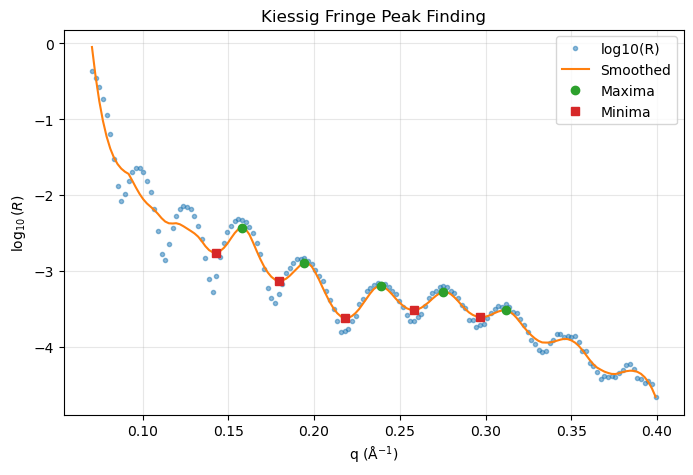


Theoretical electron densities:
TiN:    rho_e = 1.473 e/Å^3, qc ≈ 0.0457 Å^-1
Al2O3:  rho_e = 1.167 e/Å^3, qc ≈ 0.0406 Å^-1


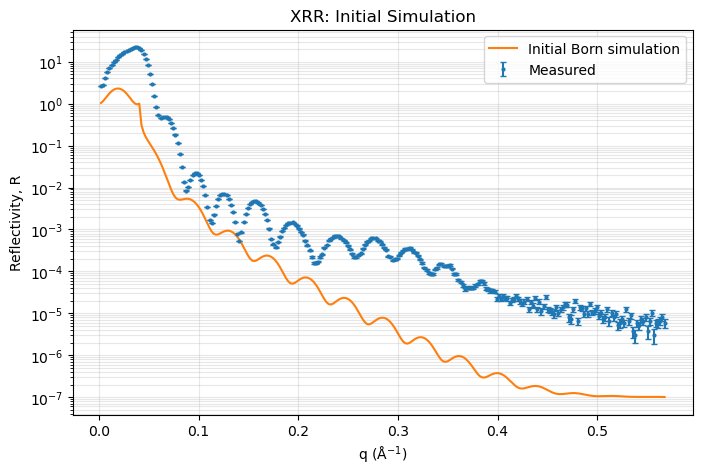


Fit results:
Thickness = 172.36 Å = 17.24 nm
TiN electron density fit = 1.412 e/Å^3
TiN theoretical electron density = 1.473 e/Å^3
Al2O3 substrate electron density fixed = 1.167 e/Å^3
Substrate/TiN roughness = 0.00 Å
TiN/Air roughness = 0.00 Å
Scale = 5.133e+00
Background = 1.767e-06


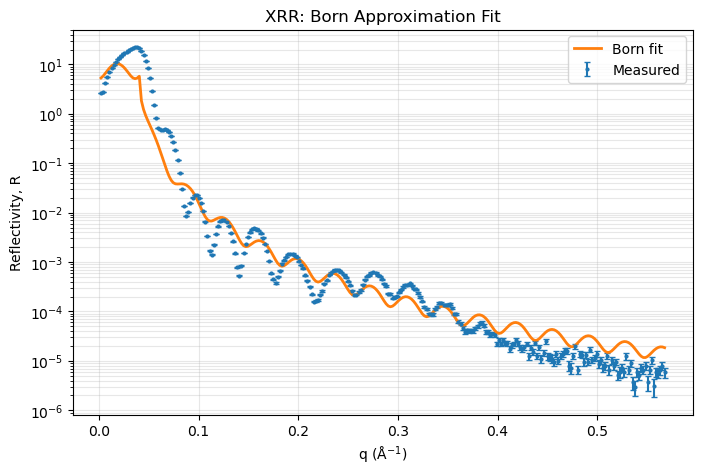


Direct method / Patterson-like interface distances:
z ≈ 152.88 Å, relative amplitude = 1.000


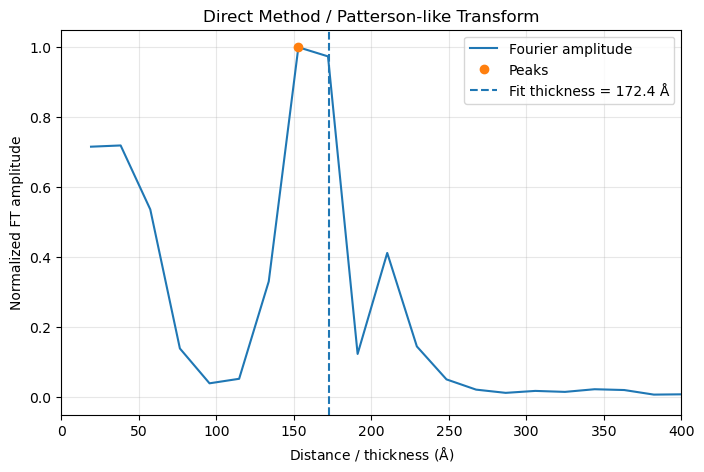

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, savgol_filter
from scipy.special import erf
from scipy.optimize import least_squares

# ============================================================
# 0. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"    # change this

# useful q range for thickness / fitting
q_min_fit = 0.07
q_max_fit = 0.40

# X-ray wavelength: Cu K-alpha
lambda_A = 1.5406  # Å

# classical electron radius
r_e = 2.8179403262e-5  # Å

# ============================================================
# 1. Load q, R, dR
# ============================================================

df = pd.read_csv(
    file_path,
    sep=r"[\s,]+",
    engine="python",
    comment="#",
    header=None
)

df = df.iloc[:, :3]
df.columns = ["q", "R", "dR"]

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(float)
R = df["R"].to_numpy(float)
dR = df["dR"].to_numpy(float)

print(df.head())
print(df.dtypes)

# ============================================================
# 2. Estimate thickness from Kiessig fringes
#    t ≈ 2π / Δq
# ============================================================

mask = (q >= q_min_fit) & (q <= q_max_fit)
q_fit = q[mask]
R_fit = R[mask]

logR = np.log10(R_fit)

# smooth logR to reduce noise
window = 21
if len(logR) <= window:
    window = len(logR) // 2 * 2 - 1
if window < 5:
    window = 5

logR_smooth = savgol_filter(logR, window_length=window, polyorder=3)

# maxima and minima of Kiessig fringes
maxima, _ = find_peaks(logR_smooth, prominence=0.08, distance=8)
minima, _ = find_peaks(-logR_smooth, prominence=0.08, distance=8)

q_maxima = q_fit[maxima]
q_minima = q_fit[minima]

def estimate_t_from_peaks(q_peaks, label):
    if len(q_peaks) < 2:
        print(f"Not enough {label} peaks found.")
        return None

    dq = np.diff(q_peaks)
    dq_mean = np.mean(dq)
    dq_std = np.std(dq)

    thickness_A = 2 * np.pi / dq_mean
    thickness_nm = thickness_A / 10

    print(f"\nThickness from {label}:")
    print(f"Average Δq = {dq_mean:.4f} ± {dq_std:.4f} Å^-1")
    print(f"t ≈ {thickness_A:.2f} Å = {thickness_nm:.2f} nm")

    return thickness_A

t_from_max = estimate_t_from_peaks(q_maxima, "maxima")
t_from_min = estimate_t_from_peaks(q_minima, "minima")

t_candidates = [x for x in [t_from_max, t_from_min] if x is not None]
t_initial = np.mean(t_candidates)

print(f"\nInitial thickness used for simulation: {t_initial:.2f} Å = {t_initial/10:.2f} nm")

# Plot peak finding result
plt.figure(figsize=(8, 5))
plt.plot(q_fit, logR, ".", alpha=0.5, label="log10(R)")
plt.plot(q_fit, logR_smooth, "-", label="Smoothed")
plt.plot(q_maxima, logR_smooth[maxima], "o", label="Maxima")
plt.plot(q_minima, logR_smooth[minima], "s", label="Minima")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R)$")
plt.title("Kiessig Fringe Peak Finding")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 3. Electron density calculation
# ============================================================

N_A = 6.02214076e23

def electron_density_from_mass_density(rho_g_cm3, molar_mass_g_mol, total_Z):
    """
    return electron density in e/Å^3
    ignoring dispersion correction f'
    """
    formula_units_cm3 = rho_g_cm3 / molar_mass_g_mol * N_A
    electrons_cm3 = formula_units_cm3 * total_Z
    electrons_A3 = electrons_cm3 / 1e24
    return electrons_A3

# TiN
rho_TiN = 5.22
M_TiN = 47.867 + 14.007
Z_TiN = 22 + 7

rho_e_TiN = electron_density_from_mass_density(rho_TiN, M_TiN, Z_TiN)

# Al2O3
rho_Al2O3 = 3.95
M_Al2O3 = 2 * 26.9815385 + 3 * 15.999
Z_Al2O3 = 2 * 13 + 3 * 8

rho_e_Al2O3 = electron_density_from_mass_density(rho_Al2O3, M_Al2O3, Z_Al2O3)

def qc_from_ed(rho_e):
    return np.sqrt(16 * np.pi * r_e * rho_e)

qc_TiN = qc_from_ed(rho_e_TiN)
qc_Al2O3 = qc_from_ed(rho_e_Al2O3)

print("\nTheoretical electron densities:")
print(f"TiN:    rho_e = {rho_e_TiN:.3f} e/Å^3, qc ≈ {qc_TiN:.4f} Å^-1")
print(f"Al2O3:  rho_e = {rho_e_Al2O3:.3f} e/Å^3, qc ≈ {qc_Al2O3:.4f} Å^-1")

# ============================================================
# 4. Born approximation simulation for Air / TiN / Al2O3
# ============================================================

def fresnel_reflectivity(q, rho_sub):
    """
    approximate Fresnel reflectivity for substrate/air interface
    using qc from substrate electron density.
    """
    qc = qc_from_ed(rho_sub)

    q_complex = q.astype(complex)
    kz0 = q_complex / 2
    kz1 = np.sqrt(q_complex**2 - qc**2 + 0j) / 2

    r = (kz0 - kz1) / (kz0 + kz1)
    return np.abs(r)**2

def born_xrr_single_layer(q, rho_sub, rho_film, thickness, sigma_sub_film, sigma_film_air, scale=1.0, background=0.0):
    """
    Air / film / substrate Born approximation.

    Interfaces:
    z = 0: substrate -> film
    z = thickness: film -> air

    Electron density jumps:
    Δrho_0 = rho_film - rho_sub
    Δrho_1 = 0 - rho_film
    """

    rho_air = 0.0

    delta_rho_sub_air = rho_air - rho_sub

    delta_rho_0 = rho_film - rho_sub
    delta_rho_1 = rho_air - rho_film

    z0 = 0.0
    z1 = thickness

    # roughness damping factor for Gaussian interfaces
    amp = (
        delta_rho_0 * np.exp(1j * q * z0) * np.exp(-0.5 * (q * sigma_sub_film)**2)
        +
        delta_rho_1 * np.exp(1j * q * z1) * np.exp(-0.5 * (q * sigma_film_air)**2)
    )

    amp = amp / delta_rho_sub_air

    Rf = fresnel_reflectivity(q, rho_sub)

    R_sim = scale * Rf * np.abs(amp)**2 + background

    return R_sim.real

# initial simulation parameters
rho_sub_initial = rho_e_Al2O3
rho_film_initial = rho_e_TiN
sigma_initial = 5.0  # Å
scale_initial = 1.0
background_initial = 1e-7

R_initial = born_xrr_single_layer(
    q,
    rho_sub=rho_sub_initial,
    rho_film=rho_film_initial,
    thickness=t_initial,
    sigma_sub_film=sigma_initial,
    sigma_film_air=sigma_initial,
    scale=scale_initial,
    background=background_initial
)

plt.figure(figsize=(8, 5))
plt.errorbar(q, R, yerr=dR, fmt=".", markersize=4, capsize=2, label="Measured")
plt.plot(q, R_initial, "-", label="Initial Born simulation")
plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("XRR: Initial Simulation")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ============================================================
# 5. Fit simulation to data
# ============================================================

fit_mask = (q >= q_min_fit) & (q <= q_max_fit)
q_data = q[fit_mask]
R_data = R[fit_mask]
dR_data = dR[fit_mask]

# avoid zero uncertainty
dR_data = np.where(dR_data <= 0, np.nanmedian(dR_data[dR_data > 0]), dR_data)

def residuals(params):
    """
    params:
    [thickness, rho_film, sigma_sub_film, sigma_film_air, log10_scale, log10_background]
    """
    thickness, rho_film, sigma_sf, sigma_fa, log_scale, log_bg = params

    scale = 10**log_scale
    bg = 10**log_bg

    R_model = born_xrr_single_layer(
        q_data,
        rho_sub=rho_sub_initial,
        rho_film=rho_film,
        thickness=thickness,
        sigma_sub_film=sigma_sf,
        sigma_film_air=sigma_fa,
        scale=scale,
        background=bg
    )

    # fit in log space
    return np.log10(R_model) - np.log10(R_data)

p0 = [
    t_initial,
    rho_film_initial,
    5.0,
    5.0,
    0.0,
    -7.0
]

lower = [
    20.0,    # thickness Å
    0.5,     # film electron density
    0.0,     # roughness Å
    0.0,
    -3.0,
    -10.0
]

upper = [
    500.0,   # thickness Å
    2.5,     # film electron density
    30.0,
    30.0,
    3.0,
    -3.0
]

result = least_squares(
    residuals,
    p0,
    bounds=(lower, upper),
    max_nfev=5000
)

t_fit, rho_film_fit, sigma_sf_fit, sigma_fa_fit, log_scale_fit, log_bg_fit = result.x

scale_fit = 10**log_scale_fit
bg_fit = 10**log_bg_fit

print("\nFit results:")
print(f"Thickness = {t_fit:.2f} Å = {t_fit/10:.2f} nm")
print(f"TiN electron density fit = {rho_film_fit:.3f} e/Å^3")
print(f"TiN theoretical electron density = {rho_e_TiN:.3f} e/Å^3")
print(f"Al2O3 substrate electron density fixed = {rho_sub_initial:.3f} e/Å^3")
print(f"Substrate/TiN roughness = {sigma_sf_fit:.2f} Å")
print(f"TiN/Air roughness = {sigma_fa_fit:.2f} Å")
print(f"Scale = {scale_fit:.3e}")
print(f"Background = {bg_fit:.3e}")

R_fit_model = born_xrr_single_layer(
    q,
    rho_sub=rho_sub_initial,
    rho_film=rho_film_fit,
    thickness=t_fit,
    sigma_sub_film=sigma_sf_fit,
    sigma_film_air=sigma_fa_fit,
    scale=scale_fit,
    background=bg_fit
)

plt.figure(figsize=(8, 5))
plt.errorbar(q, R, yerr=dR, fmt=".", markersize=4, capsize=2, label="Measured")
plt.plot(q, R_fit_model, "-", linewidth=2, label="Born fit")
plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("XRR: Born Approximation Fit")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ============================================================
# 6. Direct method / Patterson-like Fourier transform
# ============================================================

# use q^4 R approximately to remove Fresnel decay
q_dm = q_fit
signal = R_fit * q_fit**4

# subtract slow mean
signal = signal - np.mean(signal)

# interpolate to uniform q grid
N = 4096
q_uniform = np.linspace(q_dm.min(), q_dm.max(), N)
signal_uniform = np.interp(q_uniform, q_dm, signal)

# window to reduce FFT edge artifacts
signal_uniform *= np.hanning(N)

dq = q_uniform[1] - q_uniform[0]

FT = np.fft.fft(signal_uniform)
freq = np.fft.fftfreq(N, d=dq)

z = 2 * np.pi * freq
positive = z > 0

z_pos = z[positive]
P = np.abs(FT[positive])
P = P / np.max(P)

peaks, _ = find_peaks(P, prominence=0.03, distance=30)

print("\nDirect method / Patterson-like interface distances:")
for zz, amp in zip(z_pos[peaks[:10]], P[peaks[:10]]):
    print(f"z ≈ {zz:.2f} Å, relative amplitude = {amp:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(z_pos, P, label="Fourier amplitude")
plt.plot(z_pos[peaks], P[peaks], "o", label="Peaks")
plt.axvline(t_fit, linestyle="--", label=f"Fit thickness = {t_fit:.1f} Å")
plt.xlim(0, 400)
plt.xlabel(r"Distance / thickness ($\mathrm{\AA}$)")
plt.ylabel("Normalized FT amplitude")
plt.title("Direct Method / Patterson-like Transform")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Fitting

===== Fixed-density Born single-layer fit =====
Model: Air / TiN / Al2O3
TiN thickness = 171.94 Å = 17.19 nm
TiN electron density fixed = 1.470 e/Å³
Al2O3 electron density fixed = 1.170 e/Å³
Air/TiN roughness = 0.20 Å
TiN/Al2O3 roughness = 0.20 Å
Scale factor = 4.541
Background = 1.000e-05
Cost = 3.6214e+00


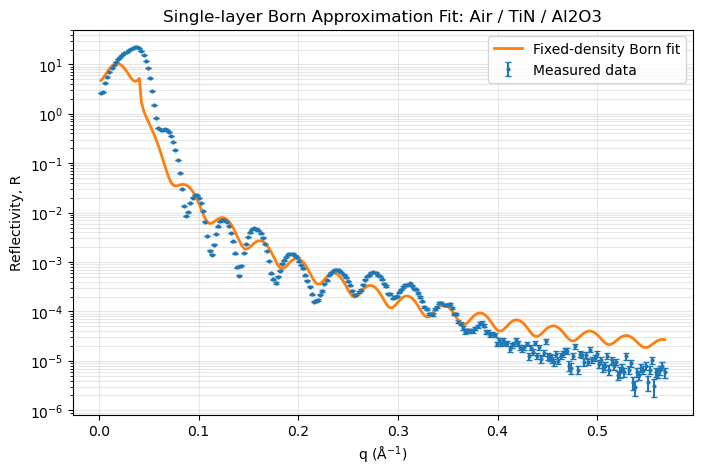

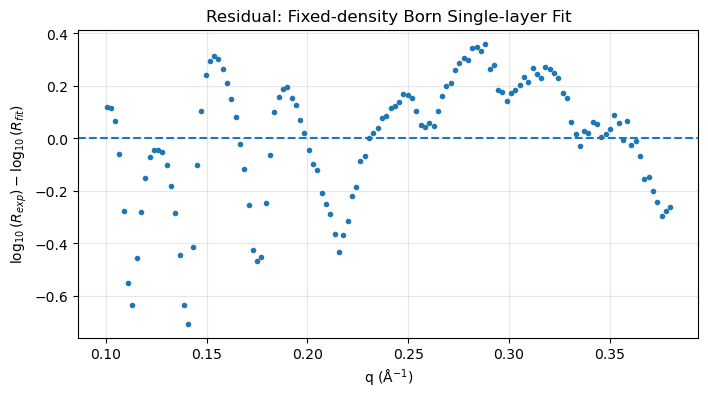

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"   # columns: q, R, dR

q_min_fit = 0.10
q_max_fit = 0.38

# Fixed electron densities, e/Å^3
rho_TiN = 1.47
rho_sub = 1.17   # Al2O3

# Initial thickness from Kiessig fringes
t_init = 163.0   # Å

# Classical electron radius
r_e = 2.8179403262e-5  # Å

# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(
    file_path,
    sep=r"[\s,]+",
    engine="python",
    comment="#",
    header=None
)

df = df.iloc[:, :3]
df.columns = ["q", "R", "dR"]

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(float)
R = df["R"].to_numpy(float)
dR = df["dR"].to_numpy(float)

fit_mask = (q >= q_min_fit) & (q <= q_max_fit)
q_fit = q[fit_mask]
R_fit = R[fit_mask]

# ============================================================
# 3. Fresnel reflectivity
# ============================================================

def fresnel_reflectivity(q, rho_sub):
    q = np.asarray(q, dtype=float)
    q_complex = q.astype(complex)

    qc = np.sqrt(16 * np.pi * r_e * rho_sub)

    kz_air = q_complex / 2
    kz_sub = np.sqrt(q_complex**2 - qc**2 + 0j) / 2

    r = (kz_air - kz_sub) / (kz_air + kz_sub)

    return np.abs(r)**2

# ============================================================
# 4. Born approximation: single-layer model
# ============================================================

def born_single_layer_fixed_density(
    q,
    thickness,
    sigma_air_TiN,
    sigma_TiN_sub,
    scale,
    background,
    rho_TiN=rho_TiN,
    rho_sub=rho_sub
):
    """
    Born approximation model:
    Air / TiN / Al2O3

    Fixed:
        rho_TiN, rho_sub

    Fitted:
        thickness, roughnesses, scale, background
    """

    q = np.asarray(q, dtype=float)

    rho_air = 0.0

    # density jumps
    drho01 = rho_TiN - rho_air
    drho12 = rho_sub - rho_TiN
    drho_sub_air = rho_sub - rho_air

    # interface positions
    z0 = 0.0
    z1 = thickness

    amp = (
        drho01
        * np.exp(1j * q * z0)
        * np.exp(-0.5 * (q * sigma_air_TiN)**2)
        +
        drho12
        * np.exp(1j * q * z1)
        * np.exp(-0.5 * (q * sigma_TiN_sub)**2)
    )

    amp_norm = amp / drho_sub_air

    R_F = fresnel_reflectivity(q, rho_sub)

    R_model = scale * R_F * np.abs(amp_norm)**2 + background

    return R_model

# ============================================================
# 5. Residual
# ============================================================

def residual(params):
    """
    params:
    thickness,
    sigma_air_TiN,
    sigma_TiN_sub,
    log10_scale,
    log10_background
    """

    thickness, sigma_air, sigma_sub, log_scale, log_bg = params

    scale = 10**log_scale
    background = 10**log_bg

    R_model = born_single_layer_fixed_density(
        q_fit,
        thickness=thickness,
        sigma_air_TiN=sigma_air,
        sigma_TiN_sub=sigma_sub,
        scale=scale,
        background=background
    )

    return np.log10(R_model) - np.log10(R_fit)

# ============================================================
# 6. Bounds
# ============================================================

lower = [
    140.0,          # thickness, Å
    0.2,            # Air/TiN roughness, Å
    0.2,            # TiN/Al2O3 roughness, Å
    np.log10(0.1),  # scale
    -10.0           # background
]

upper = [
    190.0,          # thickness, Å
    15.0,           # Air/TiN roughness, Å
    15.0,           # TiN/Al2O3 roughness, Å
    np.log10(10.0), # scale
    -5.0            # background
]

# ============================================================
# 7. Multi-start fitting
# ============================================================

initial_guesses = []

for t0 in [145, 155, 163, 170, 180]:
    for sigma_air0 in [0.5, 1, 3, 5, 8, 12]:
        for sigma_sub0 in [0.5, 1, 3, 5, 8, 12]:
            for scale0 in [0.5, 1.0, 2.0, 5.0]:
                initial_guesses.append([
                    t0,
                    sigma_air0,
                    sigma_sub0,
                    np.log10(scale0),
                    -7.0
                ])

best_result = None
best_cost = np.inf

for p0 in initial_guesses:
    result = least_squares(
        residual,
        p0,
        bounds=(lower, upper),
        max_nfev=10000
    )

    if result.cost < best_cost:
        best_cost = result.cost
        best_result = result

if best_result is None:
    raise RuntimeError("No successful fit.")

# ============================================================
# 8. Extract best-fit results
# ============================================================

t_fit, sigma_air_fit, sigma_sub_fit, log_scale_fit, log_bg_fit = best_result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit

R_best = born_single_layer_fixed_density(
    q,
    thickness=t_fit,
    sigma_air_TiN=sigma_air_fit,
    sigma_TiN_sub=sigma_sub_fit,
    scale=scale_fit,
    background=background_fit
)

R_fit_best = born_single_layer_fixed_density(
    q_fit,
    thickness=t_fit,
    sigma_air_TiN=sigma_air_fit,
    sigma_TiN_sub=sigma_sub_fit,
    scale=scale_fit,
    background=background_fit
)

# ============================================================
# 9. Print results
# ============================================================

print("===== Fixed-density Born single-layer fit =====")
print("Model: Air / TiN / Al2O3")
print(f"TiN thickness = {t_fit:.2f} Å = {t_fit/10:.2f} nm")
print(f"TiN electron density fixed = {rho_TiN:.3f} e/Å³")
print(f"Al2O3 electron density fixed = {rho_sub:.3f} e/Å³")
print(f"Air/TiN roughness = {sigma_air_fit:.2f} Å")
print(f"TiN/Al2O3 roughness = {sigma_sub_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3f}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {best_result.cost:.4e}")

# ============================================================
# 10. Plot best fit
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt=".",
    markersize=4,
    capsize=2,
    label="Measured data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    label="Fixed-density Born fit"
)

plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Single-layer Born Approximation Fit: Air / TiN / Al2O3")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ============================================================
# 11. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(q_fit, np.log10(R_fit) - np.log10(R_fit_best), ".")
plt.axhline(0, linestyle="--")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_{exp}) - \log_{10}(R_{fit})$")
plt.title("Residual: Fixed-density Born Single-layer Fit")
plt.grid(alpha=0.3)
plt.show()

===== Physically constrained Born single-layer fit =====
Model: Air / TiN / Al2O3
Fitting q range = 0.10–0.30 Å^-1
TiN thickness = 143.42 Å = 14.34 nm
TiN electron density fixed = 1.470 e/Å³
Al2O3 electron density fixed = 1.170 e/Å³
Air/TiN roughness = 1.00 Å
TiN/Al2O3 roughness = 1.00 Å
Scale factor = 2.000
Background = 1.000e-06
Cost = 9.3307e+00


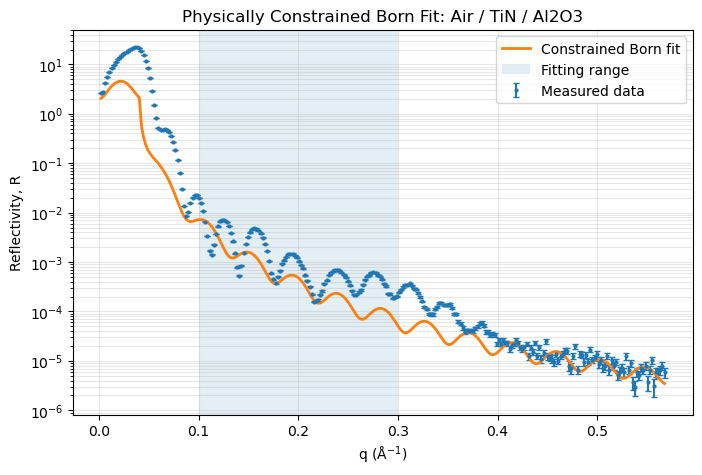

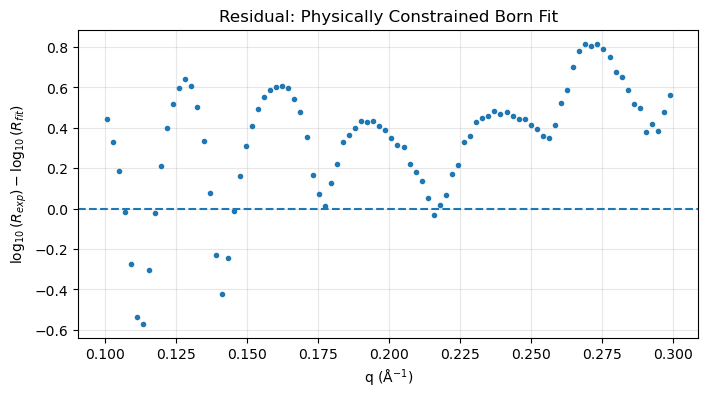

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"  # columns: q, R, dR

q_min_fit = 0.10
q_max_fit = 0.30

rho_TiN = 1.47     # e/Å^3
rho_sub = 1.17     # Al2O3, e/Å^3
t_init = 163.0     # Å

r_e = 2.8179403262e-5  # Å

# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(
    file_path,
    sep=r"[\s,]+",
    engine="python",
    comment="#",
    header=None
)

df = df.iloc[:, :3]
df.columns = ["q", "R", "dR"]

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(float)
R = df["R"].to_numpy(float)
dR = df["dR"].to_numpy(float)

fit_mask = (q >= q_min_fit) & (q <= q_max_fit)
q_fit = q[fit_mask]
R_fit = R[fit_mask]

# ============================================================
# 3. Fresnel reflectivity
# ============================================================

def fresnel_reflectivity(q, rho_sub):
    q = np.asarray(q, dtype=float)
    q_complex = q.astype(complex)

    qc = np.sqrt(16 * np.pi * r_e * rho_sub)

    kz_air = q_complex / 2
    kz_sub = np.sqrt(q_complex**2 - qc**2 + 0j) / 2

    r = (kz_air - kz_sub) / (kz_air + kz_sub)
    return np.abs(r)**2

# ============================================================
# 4. Born approximation: single-layer model
# ============================================================

def born_single_layer_fixed_density(
    q,
    thickness,
    sigma_air_TiN,
    sigma_TiN_sub,
    scale,
    background
):
    q = np.asarray(q, dtype=float)

    rho_air = 0.0

    drho01 = rho_TiN - rho_air
    drho12 = rho_sub - rho_TiN
    drho_sub_air = rho_sub - rho_air

    z0 = 0.0
    z1 = thickness

    amp = (
        drho01
        * np.exp(1j * q * z0)
        * np.exp(-0.5 * (q * sigma_air_TiN)**2)
        +
        drho12
        * np.exp(1j * q * z1)
        * np.exp(-0.5 * (q * sigma_TiN_sub)**2)
    )

    amp_norm = amp / drho_sub_air

    R_F = fresnel_reflectivity(q, rho_sub)

    R_model = scale * R_F * np.abs(amp_norm)**2 + background

    return R_model

# ============================================================
# 5. Residual
# ============================================================

def residual(params):
    thickness, sigma_air, sigma_sub, log_scale, log_bg = params

    scale = 10**log_scale
    background = 10**log_bg

    R_model = born_single_layer_fixed_density(
        q_fit,
        thickness=thickness,
        sigma_air_TiN=sigma_air,
        sigma_TiN_sub=sigma_sub,
        scale=scale,
        background=background
    )

    return np.log10(R_model) - np.log10(R_fit)

# ============================================================
# 6. Physically constrained bounds
# ============================================================

lower = [
    140.0,          # thickness, Å
    1.0,            # Air/TiN roughness, Å
    1.0,            # TiN/Al2O3 roughness, Å
    np.log10(0.5),  # scale
    -9.0            # background
]

upper = [
    190.0,          # thickness, Å
    12.0,           # Air/TiN roughness, Å
    12.0,           # TiN/Al2O3 roughness, Å
    np.log10(2.0),  # scale
    -6.0            # background
]

# ============================================================
# 7. Multi-start fitting
# ============================================================

initial_guesses = []

for t0 in [145, 155, 163, 170, 180]:
    for sigma_air0 in [1, 2, 4, 6, 8, 10]:
        for sigma_sub0 in [1, 2, 4, 6, 8, 10]:
            for scale0 in [0.7, 1.0, 1.5]:
                for bg0 in [-8.5, -8.0, -7.5, -7.0]:
                    initial_guesses.append([
                        t0,
                        sigma_air0,
                        sigma_sub0,
                        np.log10(scale0),
                        bg0
                    ])

best_result = None
best_cost = np.inf

for p0 in initial_guesses:
    result = least_squares(
        residual,
        p0,
        bounds=(lower, upper),
        max_nfev=10000
    )

    if result.cost < best_cost:
        best_cost = result.cost
        best_result = result

# ============================================================
# 8. Extract best-fit result
# ============================================================

t_fit, sigma_air_fit, sigma_sub_fit, log_scale_fit, log_bg_fit = best_result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit

R_best = born_single_layer_fixed_density(
    q,
    thickness=t_fit,
    sigma_air_TiN=sigma_air_fit,
    sigma_TiN_sub=sigma_sub_fit,
    scale=scale_fit,
    background=background_fit
)

R_fit_best = born_single_layer_fixed_density(
    q_fit,
    thickness=t_fit,
    sigma_air_TiN=sigma_air_fit,
    sigma_TiN_sub=sigma_sub_fit,
    scale=scale_fit,
    background=background_fit
)

# ============================================================
# 9. Print results
# ============================================================

print("===== Physically constrained Born single-layer fit =====")
print("Model: Air / TiN / Al2O3")
print(f"Fitting q range = {q_min_fit:.2f}–{q_max_fit:.2f} Å^-1")
print(f"TiN thickness = {t_fit:.2f} Å = {t_fit/10:.2f} nm")
print(f"TiN electron density fixed = {rho_TiN:.3f} e/Å³")
print(f"Al2O3 electron density fixed = {rho_sub:.3f} e/Å³")
print(f"Air/TiN roughness = {sigma_air_fit:.2f} Å")
print(f"TiN/Al2O3 roughness = {sigma_sub_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3f}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {best_result.cost:.4e}")

# ============================================================
# 10. Plot best fit
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt=".",
    markersize=4,
    capsize=2,
    label="Measured data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    label="Constrained Born fit"
)

plt.axvspan(q_min_fit, q_max_fit, alpha=0.12, label="Fitting range")

plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Physically Constrained Born Fit: Air / TiN / Al2O3")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ============================================================
# 11. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    q_fit,
    np.log10(R_fit) - np.log10(R_fit_best),
    "."
)

plt.axhline(0, linestyle="--")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_{exp}) - \log_{10}(R_{fit})$")
plt.title("Residual: Physically Constrained Born Fit")
plt.grid(alpha=0.3)
plt.show()

## Double layer

Number of initial guesses = 230
Finished 25/230, best cost = 1.2232e+01
Finished 50/230, best cost = 1.2232e+01
Finished 75/230, best cost = 1.2232e+01
Finished 100/230, best cost = 1.2232e+01
Finished 125/230, best cost = 1.2232e+01
Finished 150/230, best cost = 1.2232e+01
Finished 175/230, best cost = 1.2232e+01
Finished 200/230, best cost = 1.2232e+01
Finished 225/230, best cost = 1.2232e+01

===== Fast numba Born double-layer fit =====
Model: Air / low-density Layer 1 / TiN-like Layer 2 / Al2O3
Fitting q range = 0.10–0.30 Å^-1
Layer 1 thickness = 5.00 Å = 0.50 nm
Layer 2 thickness = 166.52 Å = 16.65 nm
Total thickness = 171.52 Å = 17.15 nm
Layer 1 electron density = 1.350 e/Å³
Layer 2 electron density fixed = 1.470 e/Å³
Al2O3 electron density fixed = 1.170 e/Å³
Air/Layer1 roughness = 1.00 Å
Layer1/Layer2 roughness = 1.00 Å
Layer2/Al2O3 roughness = 2.76 Å
Scale factor = 2.000
Background = 1.000e-06
Cost = 1.2232e+01


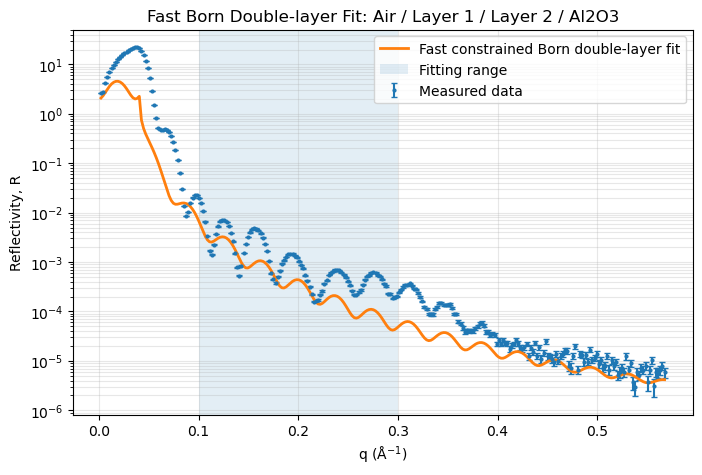

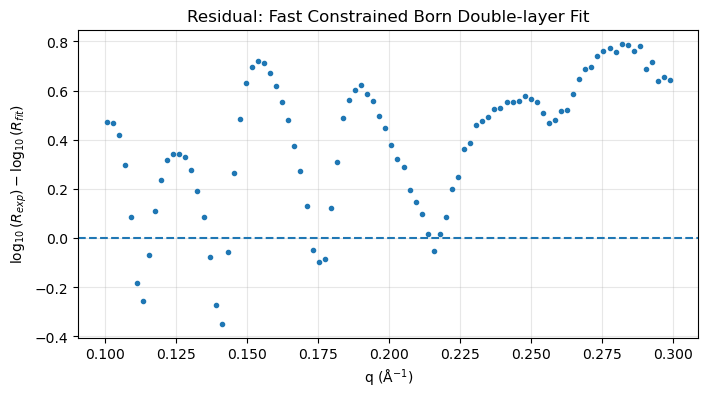

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from numba import njit

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\reduced_XRR_data.txt"

q_min_fit = 0.10
q_max_fit = 0.30

rho_air = 0.0
rho_TiN_main = 1.47
rho_sub = 1.17
total_t_target = 163.0
r_e = 2.8179403262e-5

# number of random starts
n_starts = 200
random_seed = 0

# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(
    file_path,
    sep=r"[\s,]+",
    engine="python",
    comment="#",
    header=None
)

df = df.iloc[:, :3]
df.columns = ["q", "R", "dR"]

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(np.float64)
R = df["R"].to_numpy(np.float64)
dR = df["dR"].to_numpy(np.float64)

fit_mask = (q >= q_min_fit) & (q <= q_max_fit)
q_fit = q[fit_mask].astype(np.float64)
R_fit = R[fit_mask].astype(np.float64)
logR_fit = np.log10(R_fit)

# ============================================================
# 3. Precompute Fresnel reflectivity
# ============================================================

def fresnel_reflectivity_numpy(q, rho_sub):
    q_complex = q.astype(np.complex128)

    qc = np.sqrt(16 * np.pi * r_e * rho_sub)

    kz_air = q_complex / 2
    kz_sub = np.sqrt(q_complex**2 - qc**2 + 0j) / 2

    r = (kz_air - kz_sub) / (kz_air + kz_sub)
    return np.abs(r)**2

RF_all = fresnel_reflectivity_numpy(q, rho_sub).astype(np.float64)
RF_fit = fresnel_reflectivity_numpy(q_fit, rho_sub).astype(np.float64)

# ============================================================
# 4. Numba-accelerated Born double-layer model
# ============================================================

@njit(cache=True)
def born_double_layer_numba(
    q,
    RF,
    d1,
    d2,
    rho1,
    sigma01,
    sigma12,
    sigma23,
    scale,
    background,
    rho_TiN_main,
    rho_sub
):
    n = q.size
    out = np.empty(n, dtype=np.float64)

    rho0 = 0.0
    rho2 = rho_TiN_main
    rho3 = rho_sub

    drho01 = rho1 - rho0
    drho12 = rho2 - rho1
    drho23 = rho3 - rho2

    z1 = d1
    z2 = d1 + d2

    denom = rho3 - rho0

    for i in range(n):
        qi = q[i]

        damp01 = np.exp(-0.5 * (qi * sigma01) ** 2)
        damp12 = np.exp(-0.5 * (qi * sigma12) ** 2)
        damp23 = np.exp(-0.5 * (qi * sigma23) ** 2)

        # term 01: phase = 0
        real_amp = drho01 * damp01
        imag_amp = 0.0

        # term 12
        phase1 = qi * z1
        c1 = np.cos(phase1)
        s1 = np.sin(phase1)
        real_amp += drho12 * damp12 * c1
        imag_amp += drho12 * damp12 * s1

        # term 23
        phase2 = qi * z2
        c2 = np.cos(phase2)
        s2 = np.sin(phase2)
        real_amp += drho23 * damp23 * c2
        imag_amp += drho23 * damp23 * s2

        real_amp /= denom
        imag_amp /= denom

        amp2 = real_amp * real_amp + imag_amp * imag_amp

        out[i] = scale * RF[i] * amp2 + background

        # avoid numerical log problems
        if out[i] <= 1e-300:
            out[i] = 1e-300

    return out

@njit(cache=True)
def residual_numba(
    params,
    q_fit,
    RF_fit,
    logR_fit,
    rho_TiN_main,
    rho_sub,
    total_t_target
):
    d1 = params[0]
    d2 = params[1]
    rho1 = params[2]
    sigma01 = params[3]
    sigma12 = params[4]
    sigma23 = params[5]
    log_scale = params[6]
    log_bg = params[7]

    scale = 10.0 ** log_scale
    background = 10.0 ** log_bg

    R_model = born_double_layer_numba(
        q_fit,
        RF_fit,
        d1,
        d2,
        rho1,
        sigma01,
        sigma12,
        sigma23,
        scale,
        background,
        rho_TiN_main,
        rho_sub
    )

    n = q_fit.size
    res = np.empty(n + 3, dtype=np.float64)

    for i in range(n):
        res[i] = np.log10(R_model[i]) - logR_fit[i]

    # physical penalties
    res[n] = ((d1 + d2) - total_t_target) / 8.0

    density_order = rho1 - rho_TiN_main
    if density_order < 0.0:
        density_order = 0.0
    res[n + 1] = density_order / 0.05

    res[n + 2] = (log_scale - 0.0) / 0.25

    return res

# wrapper for scipy
def residual_fast(params):
    return residual_numba(
        params.astype(np.float64),
        q_fit,
        RF_fit,
        logR_fit,
        rho_TiN_main,
        rho_sub,
        total_t_target
    )

# ============================================================
# 5. Bounds
# ============================================================

lower = np.array([
    5.0,
    100.0,
    0.60,
    1.0,
    1.0,
    1.0,
    np.log10(0.5),
    -9.0
], dtype=np.float64)

upper = np.array([
    50.0,
    180.0,
    1.35,
    12.0,
    12.0,
    12.0,
    np.log10(2.0),
    -6.0
], dtype=np.float64)

# ============================================================
# 6. Generate fewer but better initial guesses
# ============================================================

rng = np.random.default_rng(random_seed)

initial_guesses = []

# include several physically important guesses
for d1 in [8, 12, 18, 25, 35, 45]:
    for total_d in [155, 160, 163, 168, 175]:
        d2 = total_d - d1
        if lower[1] <= d2 <= upper[1]:
            initial_guesses.append([
                d1, d2, 1.0, 4.0, 4.0, 4.0, 0.0, -7.5
            ])

# random starts
for _ in range(n_starts):
    d1 = rng.uniform(5, 50)

    # sample total thickness near target instead of arbitrary d2
    total_d = rng.normal(total_t_target, 8.0)
    total_d = np.clip(total_d, 145, 180)

    d2 = total_d - d1

    if d2 < lower[1] or d2 > upper[1]:
        d2 = rng.uniform(lower[1], upper[1])

    rho1 = rng.uniform(0.60, 1.35)
    sigma01 = rng.uniform(1.0, 12.0)
    sigma12 = rng.uniform(1.0, 12.0)
    sigma23 = rng.uniform(1.0, 12.0)
    log_scale = rng.uniform(np.log10(0.5), np.log10(2.0))
    log_bg = rng.uniform(-9.0, -6.0)

    initial_guesses.append([
        d1, d2, rho1, sigma01, sigma12, sigma23, log_scale, log_bg
    ])

initial_guesses = np.array(initial_guesses, dtype=np.float64)

print(f"Number of initial guesses = {len(initial_guesses)}")

# ============================================================
# 7. Warm up numba compilation
# ============================================================

_ = residual_fast(initial_guesses[0])

# ============================================================
# 8. Multi-start fitting
# ============================================================

best_result = None
best_cost = np.inf

for i, p0 in enumerate(initial_guesses):
    result = least_squares(
        residual_fast,
        p0,
        bounds=(lower, upper),
        max_nfev=1000,
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8
    )

    if result.cost < best_cost:
        best_cost = result.cost
        best_result = result

    if (i + 1) % 25 == 0:
        print(f"Finished {i+1}/{len(initial_guesses)}, best cost = {best_cost:.4e}")

if best_result is None:
    raise RuntimeError("No successful fit.")

# ============================================================
# 9. Extract best-fit results
# ============================================================

d1_fit, d2_fit, rho1_fit, sigma01_fit, sigma12_fit, sigma23_fit, log_scale_fit, log_bg_fit = best_result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit
rho2_fit = rho_TiN_main

R_best = born_double_layer_numba(
    q.astype(np.float64),
    RF_all,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

R_fit_best = born_double_layer_numba(
    q_fit,
    RF_fit,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

# ============================================================
# 10. Print results
# ============================================================

print("\n===== Fast numba Born double-layer fit =====")
print("Model: Air / low-density Layer 1 / TiN-like Layer 2 / Al2O3")
print(f"Fitting q range = {q_min_fit:.2f}–{q_max_fit:.2f} Å^-1")
print(f"Layer 1 thickness = {d1_fit:.2f} Å = {d1_fit/10:.2f} nm")
print(f"Layer 2 thickness = {d2_fit:.2f} Å = {d2_fit/10:.2f} nm")
print(f"Total thickness = {d1_fit + d2_fit:.2f} Å = {(d1_fit+d2_fit)/10:.2f} nm")
print(f"Layer 1 electron density = {rho1_fit:.3f} e/Å³")
print(f"Layer 2 electron density fixed = {rho2_fit:.3f} e/Å³")
print(f"Al2O3 electron density fixed = {rho_sub:.3f} e/Å³")
print(f"Air/Layer1 roughness = {sigma01_fit:.2f} Å")
print(f"Layer1/Layer2 roughness = {sigma12_fit:.2f} Å")
print(f"Layer2/Al2O3 roughness = {sigma23_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3f}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {best_result.cost:.4e}")

# ============================================================
# 11. Plot best fit
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt=".",
    markersize=4,
    capsize=2,
    label="Measured data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    label="Fast constrained Born double-layer fit"
)

plt.axvspan(q_min_fit, q_max_fit, alpha=0.12, label="Fitting range")

plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Fast Born Double-layer Fit: Air / Layer 1 / Layer 2 / Al2O3")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ============================================================
# 12. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    q_fit,
    np.log10(R_fit) - np.log10(R_fit_best),
    "."
)

plt.axhline(0, linestyle="--")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_{exp}) - \log_{10}(R_{fit})$")
plt.title("Residual: Fast Constrained Born Double-layer Fit")
plt.grid(alpha=0.3)
plt.show()

Number of new initial guesses = 75201
Finished 100/75201, best cost = 2.9752e+00
Finished 200/75201, best cost = 2.9752e+00
Finished 300/75201, best cost = 2.9752e+00
Finished 400/75201, best cost = 2.9752e+00
Finished 500/75201, best cost = 2.9752e+00
Finished 600/75201, best cost = 2.9752e+00
Finished 700/75201, best cost = 2.9752e+00
Finished 800/75201, best cost = 2.9752e+00
Finished 900/75201, best cost = 2.9752e+00
Finished 1000/75201, best cost = 2.9752e+00
Finished 1100/75201, best cost = 2.9752e+00
Finished 1200/75201, best cost = 2.9752e+00
Finished 1300/75201, best cost = 2.9752e+00
Finished 1400/75201, best cost = 2.9752e+00
Finished 1500/75201, best cost = 2.9752e+00
Finished 1600/75201, best cost = 2.9752e+00
Finished 1700/75201, best cost = 2.9752e+00
Finished 1800/75201, best cost = 2.9752e+00
Finished 1900/75201, best cost = 2.9752e+00
Finished 2000/75201, best cost = 2.9752e+00
Finished 2100/75201, best cost = 2.9752e+00
Finished 2200/75201, best cost = 2.9752e+00
Fin

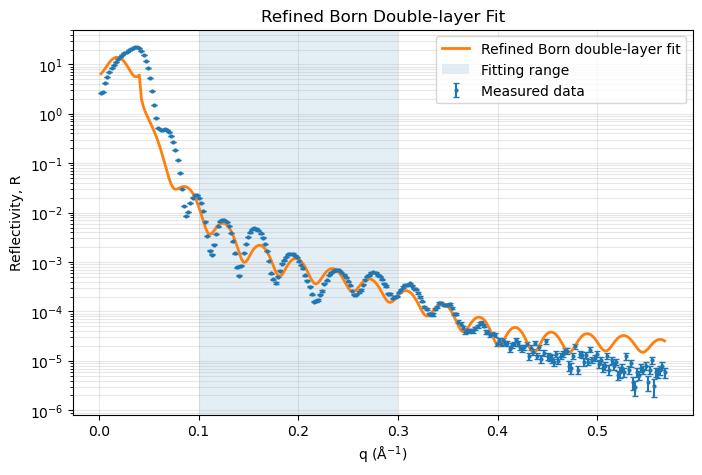

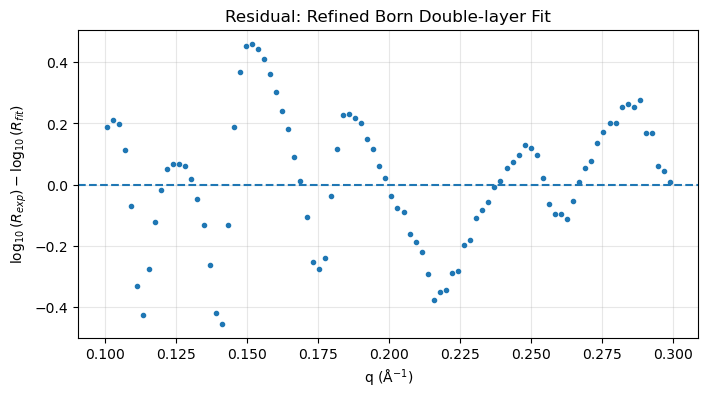

In [28]:
# ============================================================
# Next-cell refinement: allow larger amplitude
# ============================================================

from numba import njit
from scipy.optimize import least_squares
import numpy as np

# New bounds: allow stronger amplitude
lower2 = np.array([
    2.0,              # d1, Å
    100.0,            # d2, Å
    0.60,             # rho1
    0.2,              # sigma01
    0.2,              # sigma12
    0.2,              # sigma23
    np.log10(0.3),    # scale
    -10.0             # background
], dtype=np.float64)

upper2 = np.array([
    60.0,             # d1, Å
    190.0,            # d2, Å
    1.45,             # rho1, closer to TiN but still <= 1.47
    15.0,             # sigma01
    15.0,             # sigma12
    15.0,             # sigma23
    np.log10(8.0),    # scale, previously too restrictive
    -5.5              # background
], dtype=np.float64)


@njit(cache=True)
def residual_numba_v2(
    params,
    q_fit,
    RF_fit,
    logR_fit,
    rho_TiN_main,
    rho_sub,
    total_t_target
):
    d1 = params[0]
    d2 = params[1]
    rho1 = params[2]
    sigma01 = params[3]
    sigma12 = params[4]
    sigma23 = params[5]
    log_scale = params[6]
    log_bg = params[7]

    scale = 10.0 ** log_scale
    background = 10.0 ** log_bg

    R_model = born_double_layer_numba(
        q_fit,
        RF_fit,
        d1,
        d2,
        rho1,
        sigma01,
        sigma12,
        sigma23,
        scale,
        background,
        rho_TiN_main,
        rho_sub
    )

    n = q_fit.size
    res = np.empty(n + 3, dtype=np.float64)

    for i in range(n):
        res[i] = np.log10(R_model[i]) - logR_fit[i]

    # weaker total-thickness penalty
    res[n] = ((d1 + d2) - total_t_target) / 12.0

    # keep rho1 below main TiN
    density_order = rho1 - rho_TiN_main
    if density_order < 0.0:
        density_order = 0.0
    res[n + 1] = density_order / 0.05

    # much weaker scale penalty
    res[n + 2] = (log_scale - 0.0) / 0.75

    return res


def residual_fast_v2(params):
    return residual_numba_v2(
        params.astype(np.float64),
        q_fit,
        RF_fit,
        logR_fit,
        rho_TiN_main,
        rho_sub,
        total_t_target
    )


# ============================================================
# Generate new starting points around previous best
# ============================================================

rng = np.random.default_rng(1)

initial_guesses2 = []

# include previous best result
p_best_old = best_result.x.copy()
p_best_old = np.clip(p_best_old, lower2, upper2)
initial_guesses2.append(p_best_old)

# manual guesses with larger scale and smaller roughness
for d1 in [2, 5, 8, 12, 20, 35]:
    for total_d in [160, 165, 170, 175, 180]:
        d2 = total_d - d1
        if d2 < lower2[1] or d2 > upper2[1]:
            continue

        for rho1 in [0.9, 1.1, 1.25, 1.35, 1.43]:
            for sigma01 in [0.2, 0.5, 1, 2, 4]:
                for sigma12 in [0.2, 0.5, 1, 2, 4]:
                    for sigma23 in [0.5, 1, 2, 4, 8]:
                        for scale0 in [2, 3, 5, 7]:
                            initial_guesses2.append([
                                d1,
                                d2,
                                rho1,
                                sigma01,
                                sigma12,
                                sigma23,
                                np.log10(scale0),
                                -7.0
                            ])

# add random starts
for _ in range(200):
    d1 = rng.uniform(2, 60)
    total_d = rng.normal(170, 10)
    total_d = np.clip(total_d, 150, 190)
    d2 = total_d - d1

    if d2 < lower2[1] or d2 > upper2[1]:
        d2 = rng.uniform(lower2[1], upper2[1])

    initial_guesses2.append([
        d1,
        d2,
        rng.uniform(0.6, 1.45),
        rng.uniform(0.2, 8),
        rng.uniform(0.2, 8),
        rng.uniform(0.2, 12),
        rng.uniform(np.log10(0.5), np.log10(8.0)),
        rng.uniform(-9.5, -5.8)
    ])

initial_guesses2 = np.array(initial_guesses2, dtype=np.float64)

print("Number of new initial guesses =", len(initial_guesses2))

# warm up numba
_ = residual_fast_v2(initial_guesses2[0])

# ============================================================
# Run refinement
# ============================================================

best_result2 = None
best_cost2 = np.inf

for i, p0 in enumerate(initial_guesses2):
    result = least_squares(
        residual_fast_v2,
        p0,
        bounds=(lower2, upper2),
        max_nfev=1500,
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8
    )

    if result.cost < best_cost2:
        best_cost2 = result.cost
        best_result2 = result

    if (i + 1) % 100 == 0:
        print(f"Finished {i+1}/{len(initial_guesses2)}, best cost = {best_cost2:.4e}")

# replace old best result
best_result = best_result2

# ============================================================
# Extract and plot
# ============================================================

d1_fit, d2_fit, rho1_fit, sigma01_fit, sigma12_fit, sigma23_fit, log_scale_fit, log_bg_fit = best_result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit
rho2_fit = rho_TiN_main

R_best = born_double_layer_numba(
    q.astype(np.float64),
    RF_all,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

R_fit_best = born_double_layer_numba(
    q_fit,
    RF_fit,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

print("\n===== Refined Born double-layer fit =====")
print(f"Layer 1 thickness = {d1_fit:.2f} Å = {d1_fit/10:.2f} nm")
print(f"Layer 2 thickness = {d2_fit:.2f} Å = {d2_fit/10:.2f} nm")
print(f"Total thickness = {d1_fit+d2_fit:.2f} Å = {(d1_fit+d2_fit)/10:.2f} nm")
print(f"Layer 1 electron density = {rho1_fit:.3f} e/Å³")
print(f"Layer 2 electron density fixed = {rho2_fit:.3f} e/Å³")
print(f"Al2O3 electron density fixed = {rho_sub:.3f} e/Å³")
print(f"Air/Layer1 roughness = {sigma01_fit:.2f} Å")
print(f"Layer1/Layer2 roughness = {sigma12_fit:.2f} Å")
print(f"Layer2/Al2O3 roughness = {sigma23_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3f}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {best_result.cost:.4e}")

plt.figure(figsize=(8, 5))
plt.errorbar(q, R, yerr=dR, fmt=".", markersize=4, capsize=2, label="Measured data")
plt.plot(q, R_best, "-", linewidth=2, label="Refined Born double-layer fit")
plt.axvspan(q_min_fit, q_max_fit, alpha=0.12, label="Fitting range")
plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Refined Born Double-layer Fit")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(q_fit, np.log10(R_fit) - np.log10(R_fit_best), ".")
plt.axhline(0, linestyle="--")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_{exp}) - \log_{10}(R_{fit})$")
plt.title("Residual: Refined Born Double-layer Fit")
plt.grid(alpha=0.3)
plt.show()

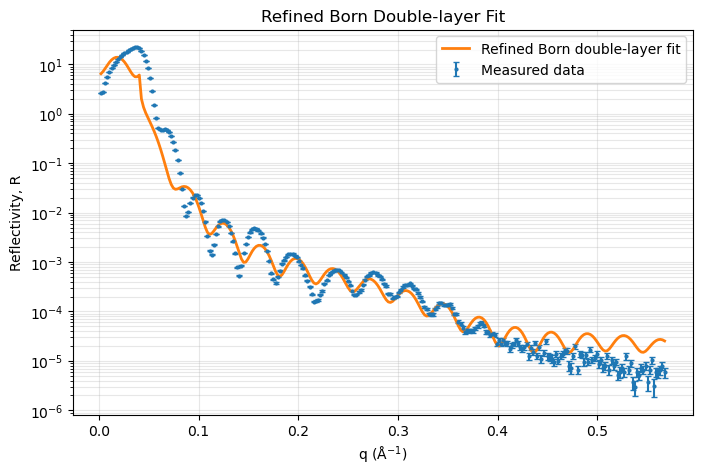

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# data
plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt=".",
    markersize=4,
    capsize=2,
    label="Measured data"
)

# fitting curve
plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    label="Refined Born double-layer fit"
)

plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Refined Born Double-layer Fit")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()